In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import gc

torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()

class IntersectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, classes, transform=None, max_samples=None, img_size=640):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.classes = classes
        self.transform = transform
        self.img_size = img_size
    
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        
        if max_samples:
            self.image_files = self.image_files[:max_samples]
        
        self.file_info = []
        for img_name in self.image_files:
            label_name = os.path.splitext(img_name)[0] + '.txt'
            label_path = os.path.join(labels_dir, label_name)
            self.file_info.append((img_name, label_path))
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name, label_path = self.file_info[idx]
        img_path = os.path.join(self.images_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        original_width, original_height = image.size
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if len(data) == 5:
                        class_id = int(data[0])
                        x_center = float(data[1])
                        y_center = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        
                        x_min = (x_center - width/2) * original_width
                        y_min = (y_center - height/2) * original_height
                        x_max = (x_center + width/2) * original_width
                        y_max = (y_center + height/2) * original_height
                        
                        x_min = max(0, x_min)
                        y_min = max(0, y_min)
                        x_max = min(original_width, x_max)
                        y_max = min(original_height, y_max)
                        
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id)
        
        if self.transform:
            image = self.transform(image)
            image_resized, scale_factor = self.resize_image(image, self.img_size)
            image_tensor = torch.tensor(np.array(image_resized)).permute(2, 0, 1).float() / 255.0
            
            if boxes:
                boxes = torch.tensor(boxes, dtype=torch.float32)
                boxes *= scale_factor
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            image_resized, scale_factor = self.resize_image(image, self.img_size)
            image_tensor = torch.tensor(np.array(image_resized)).permute(2, 0, 1).float() / 255.0
            
            if boxes:
                boxes = torch.tensor(boxes, dtype=torch.float32)
                boxes *= scale_factor
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
        
        target = {
            'boxes': boxes if isinstance(boxes, torch.Tensor) else torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros(0, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
            'area': (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if len(boxes) > 0 else torch.zeros(0, dtype=torch.float32),
            'iscrowd': torch.zeros(len(boxes) if len(boxes) > 0 else 0, dtype=torch.int64)
        }
            
        return image_tensor, target
    
    def resize_image(self, image, target_size):
        """Ресайз изображения с сохранением пропорций и возвращает scale factor"""
        original_width, original_height = image.size
        
        scale = min(target_size / original_width, target_size / original_height)
        new_width = int(original_width * scale)
        new_height = int(original_height * scale)
        
        image_resized = image.resize((new_width, new_height), Image.BILINEAR)
        
        return image_resized, scale

with open('/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/classes.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")

Classes: ['vehicle', 'bus', 'bicycle', 'pedestrian', 'engine', 'truck', 'tricycle', 'obstacle']


Визуализация bounding boxes:


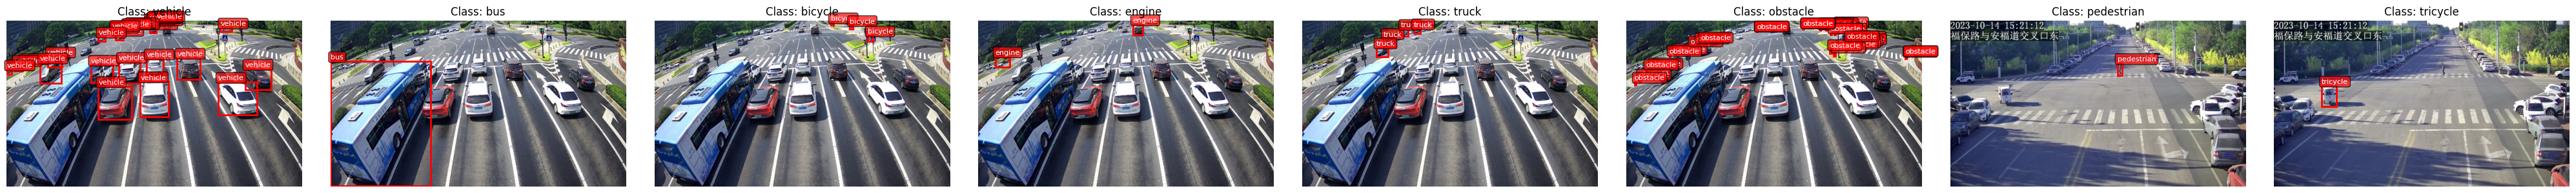

Найдены примеры для классов: ['vehicle', 'bus', 'bicycle', 'engine', 'truck', 'obstacle', 'pedestrian', 'tricycle']


In [2]:
def visualize_annotations(dataset, classes, num_samples=3):
    """Визуализация с bounding boxes"""
    
    class_examples = {}
    
    for i in range(min(500, len(dataset))):
        if len(class_examples) == len(classes):
            break
            
        image_tensor, target = dataset[i]
        
        image_np = image_tensor.permute(1, 2, 0).numpy()
        
        for label in target['labels'].unique():
            label_idx = label.item()
            if label_idx not in class_examples:
                class_examples[label_idx] = (image_np, target, i)
    
    fig, axes = plt.subplots(1, len(class_examples), figsize=(5*len(class_examples), 5))

    
    for idx, (class_id, (image_np, target, orig_idx)) in enumerate(class_examples.items()):
        ax = axes[idx]
        ax.imshow(image_np)
        ax.set_title(f'Class: {classes[class_id]}')
        ax.axis('off')
        
        for box, label in zip(target['boxes'], target['labels']):
            if label == class_id:
                x_min, y_min, x_max, y_max = box
                width = x_max - x_min
                height = y_max - y_min
                
                if width > 0 and height > 0:
                    rect = patches.Rectangle(
                        (x_min, y_min), width, height, 
                        linewidth=2, edgecolor='r', facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    ax.text(x_min, y_min-5, classes[label.item()], 
                           bbox=dict(boxstyle="round", fc="red", alpha=0.7),
                           fontsize=8, color='white')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Найдены примеры для классов: {[classes[i] for i in class_examples.keys()]}")

train_dataset = IntersectionDataset(
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/images/train',
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/labels/train',
    classes,
    max_samples=6000
)

print("Визуализация bounding boxes:")
visualize_annotations(train_dataset, classes)


=== Анализ Corrected Train Dataset ===
Processing 0/5483...
Processing 100/5483...
Processing 200/5483...
Processing 300/5483...
Processing 400/5483...
Processing 500/5483...
Processing 600/5483...
Processing 700/5483...
Processing 800/5483...
Processing 900/5483...
Processing 1000/5483...
Processing 1100/5483...
Processing 1200/5483...
Processing 1300/5483...
Processing 1400/5483...
Processing 1500/5483...
Processing 1600/5483...
Processing 1700/5483...
Processing 1800/5483...
Processing 1900/5483...
Processing 2000/5483...
Processing 2100/5483...
Processing 2200/5483...
Processing 2300/5483...
Processing 2400/5483...
Processing 2500/5483...
Processing 2600/5483...
Processing 2700/5483...
Processing 2800/5483...
Processing 2900/5483...
Processing 3000/5483...
Processing 3100/5483...
Processing 3200/5483...
Processing 3300/5483...
Processing 3400/5483...
Processing 3500/5483...
Processing 3600/5483...
Processing 3700/5483...
Processing 3800/5483...
Processing 3900/5483...
Processing 4

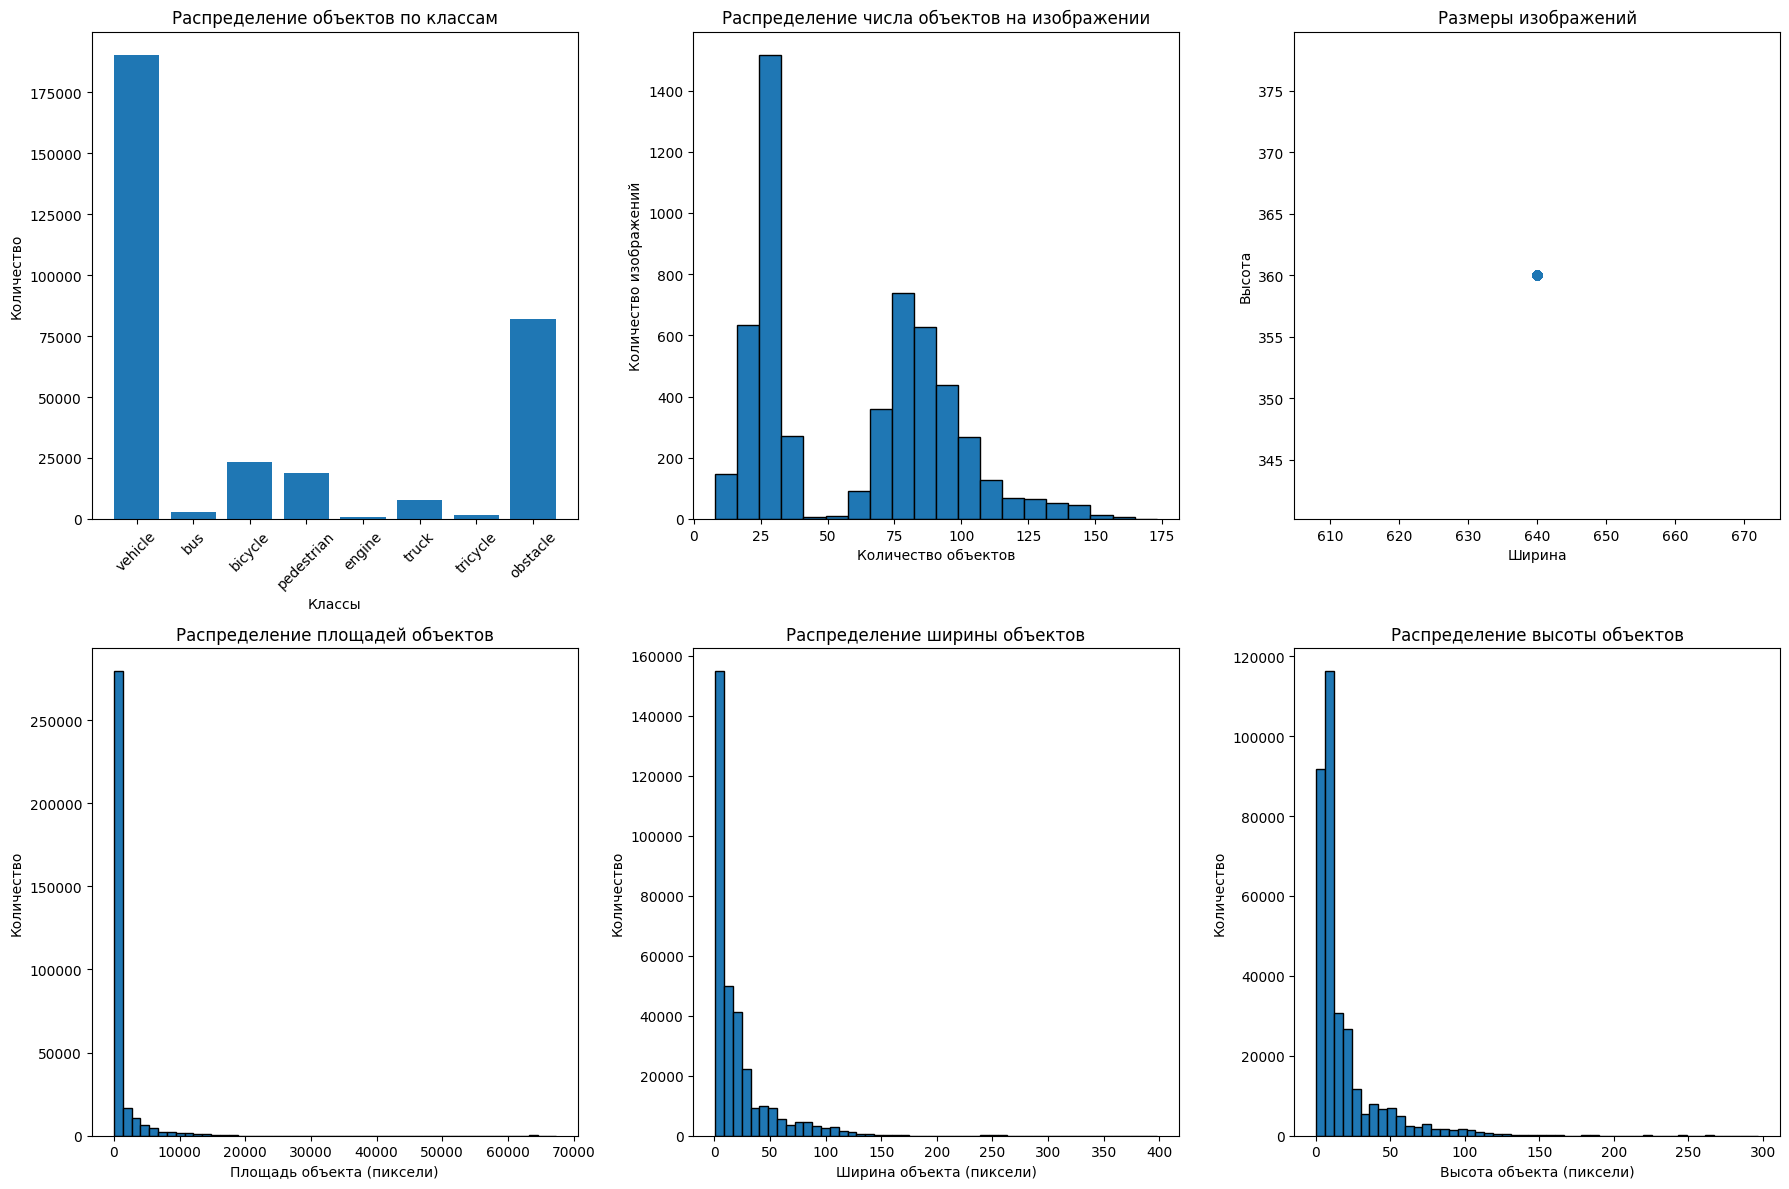

Всего изображений: 5483
Всего объектов: 327825
Среднее количество объектов на изображение: 59.79
Распределение по классам:
  vehicle: 190417
  bus: 2816
  bicycle: 23396
  pedestrian: 19005
  engine: 642
  truck: 7749
  tricycle: 1610
  obstacle: 82190
Средняя площадь объекта: 909.94 пикселей
Средний размер объекта: 20.6x17.7


In [3]:
def analyze_dataset(dataset, dataset_name, max_samples=7000):
    print(f"\n=== Анализ {dataset_name} ===")
    
    class_counts = {cls: 0 for cls in range(len(classes))}
    object_counts = []
    image_sizes = []
    bbox_areas = []
    bbox_widths = []
    bbox_heights = []
    
    num_samples = min(len(dataset), max_samples)
    
    for i in range(num_samples):
        if i % 100 == 0:
            print(f"Processing {i}/{num_samples}...")
            
        image_tensor, target = dataset[i]
        img_height, img_width = image_tensor.shape[1:]
        image_sizes.append((img_width, img_height))
        
        num_objects = len(target['labels'])
        object_counts.append(num_objects)
        
        for label in target['labels']:
            class_counts[int(label)] += 1
            
        for box in target['boxes']:
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            area = width * height
            
            bbox_widths.append(width.item())
            bbox_heights.append(height.item())
            bbox_areas.append(area.item())
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    axes[0, 0].bar(range(len(classes)), [class_counts[i] for i in range(len(classes))])
    axes[0, 0].set_title('Распределение объектов по классам')
    axes[0, 0].set_xlabel('Классы')
    axes[0, 0].set_ylabel('Количество')
    axes[0, 0].set_xticks(range(len(classes)))
    axes[0, 0].set_xticklabels(classes, rotation=45)
    
    axes[0, 1].hist(object_counts, bins=20, edgecolor='black')
    axes[0, 1].set_title('Распределение числа объектов на изображении')
    axes[0, 1].set_xlabel('Количество объектов')
    axes[0, 1].set_ylabel('Количество изображений')
    
    if image_sizes:
        widths, heights = zip(*image_sizes)
        axes[0, 2].scatter(widths, heights, alpha=0.5)
        axes[0, 2].set_title('Размеры изображений')
        axes[0, 2].set_xlabel('Ширина')
        axes[0, 2].set_ylabel('Высота')
    
    if bbox_areas:
        axes[1, 0].hist(bbox_areas, bins=50, edgecolor='black')
        axes[1, 0].set_title('Распределение площадей объектов')
        axes[1, 0].set_xlabel('Площадь объекта (пиксели)')
        axes[1, 0].set_ylabel('Количество')
    
    if bbox_widths:
        axes[1, 1].hist(bbox_widths, bins=50, edgecolor='black')
        axes[1, 1].set_title('Распределение ширины объектов')
        axes[1, 1].set_xlabel('Ширина объекта (пиксели)')
        axes[1, 1].set_ylabel('Количество')
    
    if bbox_heights:
        axes[1, 2].hist(bbox_heights, bins=50, edgecolor='black')
        axes[1, 2].set_title('Распределение высоты объектов')
        axes[1, 2].set_xlabel('Высота объекта (пиксели)')
        axes[1, 2].set_ylabel('Количество')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Всего изображений: {num_samples}")
    print(f"Всего объектов: {sum(class_counts.values())}")
    print(f"Среднее количество объектов на изображение: {np.mean(object_counts):.2f}")
    print(f"Распределение по классам:")
    for i, cls in enumerate(classes):
        print(f"  {cls}: {class_counts[i]}")
    
    if bbox_areas:
        print(f"Средняя площадь объекта: {np.mean(bbox_areas):.2f} пикселей")
        print(f"Средний размер объекта: {np.mean(bbox_widths):.1f}x{np.mean(bbox_heights):.1f}")

analyze_dataset(train_dataset, "Corrected Train Dataset", max_samples=6000)

# Часть 2

In [22]:
import torch
import torchvision
from torchvision.models.detection import fcos, retinanet, faster_rcnn
from torchvision.models.detection.fcos import FCOS_ResNet50_FPN_Weights
from torchvision.models.detection.retinanet import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision import transforms
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import time
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import tempfile
import copy

torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()

37

In [23]:
class IntersectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, classes, transform=None, max_samples=None, img_size=640):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.classes = classes
        self.transform = transform
        self.img_size = img_size
        
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        
        if max_samples:
            self.image_files = self.image_files[:max_samples]
        
        self.file_info = []
        for img_name in self.image_files:
            label_name = os.path.splitext(img_name)[0] + '.txt'
            label_path = os.path.join(labels_dir, label_name)
            self.file_info.append((img_name, label_path))
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name, label_path = self.file_info[idx]
        img_path = os.path.join(self.images_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        original_width, original_height = image.size
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if len(data) == 5:
                        class_id = int(data[0])
                        x_center = float(data[1])
                        y_center = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        
                        x_min = (x_center - width/2) * original_width
                        y_min = (y_center - height/2) * original_height
                        x_max = (x_center + width/2) * original_width
                        y_max = (y_center + height/2) * original_height
                        
                        x_min = max(0, x_min)
                        y_min = max(0, y_min)
                        x_max = min(original_width, x_max)
                        y_max = min(original_height, y_max)
                        
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id)
        
        if self.transform:
            image_tensor = self.transform(image)
            
            if boxes:
                scale_factor = self.img_size / max(original_width, original_height)
                boxes = [[x * scale_factor for x in box] for box in boxes]
                boxes = torch.tensor(boxes, dtype=torch.float32)
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                
        else:
            image_resized, scale_factor = self.resize_image(image, self.img_size)
            image_tensor = torch.tensor(np.array(image_resized)).permute(2, 0, 1).float() / 255.0
            
            if boxes:
                boxes = [[x * scale_factor for x in box] for box in boxes]
                boxes = torch.tensor(boxes, dtype=torch.float32)
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
        
        target = {}
        target['boxes'] = boxes
        target['labels'] = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros(0, dtype=torch.int64)
        target['image_id'] = torch.tensor([idx])
        
        if len(boxes) > 0:
            target['area'] = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        else:
            target['area'] = torch.zeros(0, dtype=torch.float32)
            
        target['iscrowd'] = torch.zeros(len(boxes), dtype=torch.int64)
            
        return image_tensor, target
    
    def resize_image(self, image, target_size):
        """Ресайз изображения с сохранением пропорций и возвращает scale factor"""
        original_width, original_height = image.size
        
        scale = min(target_size / original_width, target_size / original_height)
        new_width = int(original_width * scale)
        new_height = int(original_height * scale)
        
        image_resized = image.resize((new_width, new_height), Image.BILINEAR)
        
        return image_resized, scale

with open('/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/classes.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")

Classes: ['vehicle', 'bus', 'bicycle', 'pedestrian', 'engine', 'truck', 'tricycle', 'obstacle']


In [24]:
with open('/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/classes.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")

class DetectionModel:
    def __init__(self, model_type, num_classes, device, pretrained=True):
        self.model_type = model_type
        self.num_classes = num_classes
        self.device = device
        self.pretrained = pretrained
        self.model = self._create_model()
        
    def _create_model(self):
        if self.model_type == 'fcos':
            if self.pretrained:
                model = torchvision.models.detection.fcos_resnet50_fpn(
                    weights=FCOS_ResNet50_FPN_Weights.COCO_V1
                )
            else:
                model = torchvision.models.detection.fcos_resnet50_fpn(weights=None, weights_backbone=None)
            
            in_channels = model.head.classification_head.conv[0].in_channels
            num_anchors = model.head.classification_head.num_anchors
            model.head.classification_head.num_classes = self.num_classes
            
            cls_logits = torch.nn.Conv2d(
                in_channels, num_anchors * self.num_classes, 
                kernel_size=3, stride=1, padding=1
            )
            torch.nn.init.normal_(cls_logits.weight, std=0.01)
            torch.nn.init.constant_(cls_logits.bias, -np.log((1 - 0.01) / 0.01))
            model.head.classification_head.cls_logits = cls_logits
            
        elif self.model_type == 'retinanet':
            if self.pretrained:
                model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
                    weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1
                )
            else:
                model = torchvision.models.detection.retinanet_resnet50_fpn_v2(weights=None, weights_backbone=None)
            
            current_cls_logits = model.head.classification_head.cls_logits
            in_channels = current_cls_logits.in_channels
            num_anchors = model.head.classification_head.num_anchors
            
            cls_logits = torch.nn.Conv2d(
                in_channels, num_anchors * self.num_classes,
                kernel_size=3, stride=1, padding=1
            )
            torch.nn.init.normal_(cls_logits.weight, std=0.01)
            torch.nn.init.constant_(cls_logits.bias, -np.log((1 - 0.01) / 0.01))
            
            model.head.classification_head.cls_logits = cls_logits
            model.head.classification_head.num_classes = self.num_classes
            
        elif self.model_type == 'faster_rcnn':
            if self.pretrained:
                model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
                    weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
                )
            else:
                model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=None, weights_backbone=None)
            
            in_features = model.roi_heads.box_predictor.cls_score.in_features
            model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
                in_features, self.num_classes
            )
        
        return model.to(self.device)

def collate_fn(batch):
    return tuple(zip(*batch))

class COCOEvaluator:
    def __init__(self, dataset, classes):
        self.dataset = dataset
        self.classes = classes
        self.coco_gt = self._create_coco_gt()
        
    def _create_coco_gt(self):
        """Создает COCO ground truth из датасета"""
        coco_gt = {
            "images": [],
            "annotations": [],
            "categories": [],
            "info": {
                "year": 2024,
                "version": "1.0",
                "description": "Intersection-Flow-5K Dataset",
                "contributor": "",
                "url": "",
                "date_created": "2024-01-01"
            },
            "licenses": [{
                "id": 1,
                "name": "Unknown",
                "url": ""
            }]
        }
        
        for i, class_name in enumerate(self.classes):
            coco_gt["categories"].append({
                "id": i + 1,
                "name": class_name,
                "supercategory": "object"
            })
        
        annotation_id = 1
        for idx in range(len(self.dataset)):
            image_tensor, target = self.dataset[idx]
            
            coco_gt["images"].append({
                "id": idx,
                "width": int(image_tensor.shape[2]),
                "height": int(image_tensor.shape[1]),
                "file_name": f"image_{idx}.jpg",
                "license": 1,
                "flickr_url": "",
                "coco_url": "",
                "date_captured": "2024-01-01"
            })
            
            boxes = target['boxes']
            labels = target['labels']
            
            for i, (box, label) in enumerate(zip(boxes, labels)):
                x_min, y_min, x_max, y_max = box.tolist()
                width = x_max - x_min
                height = y_max - y_min
                
                if width < 1 or height < 1:
                    continue
                    
                coco_gt["annotations"].append({
                    "id": annotation_id,
                    "image_id": idx,
                    "category_id": label.item() + 1,
                    "bbox": [x_min, y_min, width, height],
                    "area": width * height,
                    "iscrowd": 0,
                    "segmentation": []
                })
                annotation_id += 1
                
        return coco_gt
    
    def evaluate(self, predictions):
        """Вычисляет mAP используя pycocotools"""
        if not predictions:
            return {'mAP': 0.0, 'mAP_50': 0.0, 'mAP_75': 0.0}
            
        try:
            with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
                gt_file = f.name
                json.dump(self.coco_gt, f)
            
            adjusted_predictions = []
            for pred in predictions:
                adjusted_pred = pred.copy()
                adjusted_pred['category_id'] = pred['category_id'] + 1
                adjusted_predictions.append(adjusted_pred)
            
            with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
                pred_file = f.name
                json.dump(adjusted_predictions, f)
            
            coco_gt = COCO(gt_file)
            
            coco_dt = coco_gt.loadRes(pred_file)
            
            coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
            coco_eval.evaluate()
            coco_eval.accumulate()
            coco_eval.summarize()
            
            map_50 = coco_eval.stats[1]
            map_75 = coco_eval.stats[2]
            map = coco_eval.stats[0]
            
            os.unlink(gt_file)
            os.unlink(pred_file)
            
            return {
                'mAP': map,
                'mAP_50': map_50,
                'mAP_75': map_75
            }
        except Exception as e:
            print(f"Error in COCO evaluation: {e}")
            return {'mAP': 0.0, 'mAP_50': 0.0, 'mAP_75': 0.0}

Classes: ['vehicle', 'bus', 'bicycle', 'pedestrian', 'engine', 'truck', 'tricycle', 'obstacle']


In [31]:
class TrainingPipeline:
    def __init__(self, model, train_loader, val_loader, device, model_name, classes):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.model_name = model_name
        self.classes = classes
        self.writer = SummaryWriter(f'runs/{model_name}_{int(time.time())}')
        
        params = [p for p in model.parameters() if p.requires_grad]
        self.optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
        
        self.lr_scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=3, gamma=0.1)
        
        self.evaluator = COCOEvaluator(val_loader.dataset, classes)
        
    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        for batch_idx, (images, targets) in enumerate(self.train_loader):
            images = [image.to(self.device) for image in images]
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            
            self.optimizer.zero_grad()
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            losses.backward()
            self.optimizer.step()
            
            total_loss += losses.item()
            num_batches += 1
            
            if batch_idx % 50 == 0:
                print(f'Epoch: {epoch}, Batch: {batch_idx}/{len(self.train_loader)}, Loss: {losses.item():.4f}')
                
                self.writer.add_scalar(f'{self.model_name}/Training batch loss', losses.item(), 
                                     epoch * len(self.train_loader) + batch_idx)
                
                for loss_name, loss_value in loss_dict.items():
                    self.writer.add_scalar(f'{self.model_name}/Training {loss_name}', loss_value.item(),
                                         epoch * len(self.train_loader) + batch_idx)
        
        avg_loss = total_loss / num_batches
        self.writer.add_scalar(f'{self.model_name}/Training epoch loss', avg_loss, epoch)
        
        return avg_loss
    
    def validate(self, epoch):
        self.model.eval()
        predictions = []
        
        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(self.val_loader):
                images = [image.to(self.device) for image in images]
                outputs = self.model(images)
                
                for i, (output, target) in enumerate(zip(outputs, targets)):
                    image_id = target['image_id'].item()
                    
                    for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
                        if score > 0.05:
                            x_min, y_min, x_max, y_max = box.cpu().tolist()
                            width = x_max - x_min
                            height = y_max - y_min
                            
                            if width < 1 or height < 1:
                                continue
                                
                            predictions.append({
                                'image_id': image_id,
                                'category_id': label.item(),
                                'bbox': [x_min, y_min, width, height],
                                'score': score.item()
                            })
                
                if batch_idx == 0:
                    self._log_detections_to_tensorboard(images, outputs, targets, epoch)
        
        if predictions:
            metrics = self.evaluator.evaluate(predictions)
            for metric_name, metric_value in metrics.items():
                self.writer.add_scalar(f'{self.model_name}/Validation {metric_name}', metric_value, epoch)
            
            return metrics, predictions
        else:
            return {'mAP': 0, 'mAP_50': 0, 'mAP_75': 0}, []
    
    def _log_detections_to_tensorboard(self, images, outputs, targets, epoch):
        """Логирование детекций в tensorboard"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        
        for idx in range(min(4, len(images))):
            ax = axes[idx]
            
            img = images[idx].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)
            
            ax.imshow(img)
            ax.set_title(f'Image {idx}')
            ax.axis('off')
            
            # Рисуем GT bounding boxes
            target = targets[idx]
            boxes_gt = target['boxes'].cpu()
            labels_gt = target['labels'].cpu()
            
            for box, label in zip(boxes_gt, labels_gt):
                x_min, y_min, x_max, y_max = box
                width = x_max - x_min
                height = y_max - y_min
                
                rect = patches.Rectangle(
                    (x_min, y_min), width, height,
                    linewidth=2, edgecolor='green', facecolor='none', alpha=0.7,
                    label='GT'
                )
                ax.add_patch(rect)
            
            output = outputs[idx]
            boxes_pred = output['boxes'].cpu()
            labels_pred = output['labels'].cpu()
            scores_pred = output['scores'].cpu()
            
            for box, label, score in zip(boxes_pred, labels_pred, scores_pred):
                if score > 0.5:
                    x_min, y_min, x_max, y_max = box
                    width = x_max - x_min
                    height = y_max - y_min
                    
                    rect = patches.Rectangle(
                        (x_min, y_min), width, height,
                        linewidth=2, edgecolor='red', facecolor='none', alpha=0.7,
                        label='Pred'
                    )
                    ax.add_patch(rect)
                    
                    ax.text(x_min, y_min-5, f'{self.classes[label.item()]}: {score:.2f}',
                           bbox=dict(boxstyle="round", fc="red", alpha=0.7),
                           fontsize=8, color='white')
        
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            fig.legend(by_label.values(), by_label.keys(), loc='lower right')
        
        self.writer.add_figure(f'{self.model_name}/Detections', fig, epoch)
        plt.close(fig)
    
    def train(self, num_epochs):
        print(f"Starting training for {self.model_name}...")
        start_time = time.time()
        
        best_map = 0
        train_losses = []
        val_metrics_history = []
        
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            
            epoch_loss = self.train_epoch(epoch)
            train_losses.append(epoch_loss)
            
            print("Running validation...")
            val_metrics, val_predictions = self.validate(epoch)
            val_metrics_history.append(val_metrics)
            
            current_map = val_metrics['mAP']
            print(f"Validation mAP: {current_map:.4f}, mAP@0.5: {val_metrics['mAP_50']:.4f}")
            
            if current_map > best_map:
                best_map = current_map
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"New best model saved with mAP: {best_map:.4f}")
                
                with open(f'best_{self.model_name}_predictions.json', 'w') as f:
                    json.dump(val_predictions, f)
            
            self.lr_scheduler.step()
            
            print(f'Epoch {epoch+1} completed. Loss: {epoch_loss:.4f}, Best mAP: {best_map:.4f}')
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")
        print(f"Best mAP: {best_map:.4f}")
        
        self.save_model()
        
        self.writer.add_scalar(f'{self.model_name}/Training time', training_time)
        self.writer.add_scalar(f'{self.model_name}/Best mAP', best_map)
        
        self.writer.close()
        
        return train_losses, best_map, training_time, val_metrics_history
    
    def save_model(self):
        """Сохраняет модель в разных форматах"""
        torch.save(self.model.state_dict(), f'{self.model_name}_final.pth')
        print(f"Model weights saved as {self.model_name}_final.pth")
        
        try:
            class WrappedModel(torch.nn.Module):
                def __init__(self, model):
                    super().__init__()
                    self.model = model
                
                def forward(self, x):
                    outputs = self.model(x)
                    if len(outputs) > 0:
                        return outputs[0]['boxes'], outputs[0]['scores']
                    else:
                        return torch.tensor([]), torch.tensor([])
            
            wrapped_model = WrappedModel(self.model)
            dummy_input = torch.randn(1, 3, 640, 640).to(self.device)
            
            torch.onnx.export(
                wrapped_model, 
                dummy_input,
                f'{self.model_name}.onnx',
                export_params=True,
                opset_version=11,
                input_names=['input'],
                output_names=['boxes', 'scores'],
                dynamic_axes={
                    'input': {0: 'batch_size'},
                    'boxes': {0: 'num_detections', 1: '4'},
                    'scores': {0: 'num_detections'}
                }
            )
            print(f"Model saved as {self.model_name}.onnx")
        except Exception as e:
            print(f"Failed to save ONNX model: {e}")

In [32]:
def get_transforms(augmented=False):
    if augmented:
        train_transform = transforms.Compose([
            transforms.Resize((640, 640)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((640, 640)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    val_transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

train_transform, val_transform = get_transforms(augmented=False)

train_dataset = IntersectionDataset(
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/images/train',
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/labels/train',
    classes,
    max_samples = 500,
    transform=train_transform
)

val_dataset = IntersectionDataset(
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/images/val',
    '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/labels/val',
    classes,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=4, collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=4, collate_fn=collate_fn
)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset: {len(val_dataset)} images")

Using device: cuda
Train dataset: 500 images
Val dataset: 722 images


In [33]:
# Часть 2.1.3 - Обучение трех моделей с Transfer Learning
models_config = [
    ('fcos', 'FCOS'),
    ('retinanet', 'RetinaNet'), 
    ('faster_rcnn', 'FasterRCNN')
]

results = {}

for model_type, model_name in models_config:
    print(f"\n{'='*50}")
    print(f"Training {model_name} with Transfer Learning")
    print(f"{'='*50}")
    
    try:
        model_wrapper = DetectionModel(model_type, len(classes), device, pretrained=True)
        model = model_wrapper.model

        pipeline = TrainingPipeline(model, train_loader, val_loader, device, f"{model_name}_TL", classes)

        train_losses, best_map, training_time, val_metrics = pipeline.train(num_epochs=5)
        
        results[model_name] = {
            'train_losses': train_losses,
            'best_map': best_map,
            'training_time': training_time,
            'val_metrics': val_metrics,
            'model_params': sum(p.numel() for p in model.parameters()),
            'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad)
        }
        
        del model, pipeline, model_wrapper
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
        
    except Exception as e:
        print(f"Error training {model_name}: {e}")
        results[model_name] = {
            'train_losses': [],
            'best_map': 0,
            'training_time': 0,
            'val_metrics': [],
            'model_params': 0,
            'trainable_params': 0
        }

print("\n" + "="*80)
print("СРАВНЕНИЕ ТРЕХ МОДЕЛЕЙ С TRANSFER LEARNING")
print("="*80)

for model_name, result in results.items():
    print(f"\n{model_name}:")
    print(f"  Best mAP: {result['best_map']:.4f}")
    print(f"  Training time: {result['training_time']:.2f}s")
    print(f"  Total parameters: {result['model_params']:,}")
    print(f"  Trainable parameters: {result['trainable_params']:,}")


Training FCOS with Transfer Learning
Starting training for FCOS_TL...

Epoch 1/5
Epoch: 0, Batch: 0/125, Loss: 2.5316
Epoch: 0, Batch: 50/125, Loss: 1.7097
Epoch: 0, Batch: 100/125, Loss: 1.5647
Running validation...
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.73s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=33.12s).
Accumulating evaluation results...
DONE (t=0.62s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.038
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.008
 Avera

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:4624: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  * torch.tensor(scale_factors[i], dtype=torch.float32)
/usr/local/lib/python3.11/dist-packages/torchvision/ops/boxes.py:166: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_x = torch.min(boxes_x, torch.tensor(width, dtype=boxes.dtype, device=boxes.device))
/usr/local/lib/python3.11/dist-packages/torchvision/ops/boxes.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_y = torch.min(boxes_y, torch.tensor(height, dty

Model saved as FCOS_TL.onnx

Training RetinaNet with Transfer Learning
Starting training for RetinaNet_TL...

Epoch 1/5
Epoch: 0, Batch: 0/125, Loss: 1.8172
Epoch: 0, Batch: 50/125, Loss: 1.1384
Epoch: 0, Batch: 100/125, Loss: 1.1993
Running validation...
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Loading and preparing results...
DONE (t=2.14s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=40.28s).
Accumulating evaluation results...
DONE (t=0.75s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area

/usr/local/lib/python3.11/dist-packages/torch/__init__.py:2132: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
/usr/local/lib/python3.11/dist-packages/torch/onnx/symbolic_opset9.py:5383: UserWarning: Exporting aten::index operator of advanced indexing in opset 11 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


Model saved as FasterRCNN_TL.onnx

СРАВНЕНИЕ ТРЕХ МОДЕЛЕЙ С TRANSFER LEARNING

FCOS:
  Best mAP: 0.0496
  Training time: 1097.61s
  Total parameters: 32,078,285
  Trainable parameters: 31,855,885

RetinaNet:
  Best mAP: 0.0082
  Training time: 1289.09s
  Total parameters: 36,477,100
  Trainable parameters: 36,251,756

FasterRCNN:
  Best mAP: 0.0308
  Training time: 1522.99s
  Total parameters: 43,286,903
  Trainable parameters: 43,061,559


In [34]:
print(f"\n{'='*50}")
print("Training FasterRCNN from scratch")
print(f"{'='*50}")

try:
    scratch_model_wrapper = DetectionModel('faster_rcnn', len(classes), device, pretrained=False)
    scratch_model = scratch_model_wrapper.model

    scratch_pipeline = TrainingPipeline(scratch_model, train_loader, val_loader, device, 'FasterRCNN_Scratch', classes)
    scratch_train_losses, scratch_best_map, scratch_training_time, scratch_val_metrics = scratch_pipeline.train(num_epochs=5)

    print(f"\nFrom Scratch Results:")
    print(f"Best mAP: {scratch_best_map:.4f}")
    print(f"Training time: {scratch_training_time:.2f}s")
    
    scratch_success = True
except Exception as e:
    print(f"Error in from scratch training: {e}")
    scratch_best_map = 0
    scratch_training_time = 0
    scratch_success = False


Training FasterRCNN from scratch
Starting training for FasterRCNN_Scratch...

Epoch 1/5
Epoch: 0, Batch: 0/125, Loss: 3.5653
Epoch: 0, Batch: 50/125, Loss: 1.0882
Epoch: 0, Batch: 100/125, Loss: 1.3926
Running validation...
Validation mAP: 0.0000, mAP@0.5: 0.0000
Epoch 1 completed. Loss: 1.5926, Best mAP: 0.0000

Epoch 2/5
Epoch: 1, Batch: 0/125, Loss: 1.4464
Epoch: 1, Batch: 50/125, Loss: 1.5316
Epoch: 1, Batch: 100/125, Loss: 1.1301
Running validation...
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.96s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.35s).
Accumulating evaluation results...
DONE (t=0.27s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Av

In [35]:
def apply_nms(predictions, iou_threshold=0.5):
    """Применяет Non-Maximum Suppression к предикшенам"""
    nms_predictions = []
    
    for prediction in predictions:
        boxes = prediction['boxes']
        scores = prediction['scores']
        labels = prediction['labels']
        
        keep_indices = torchvision.ops.nms(boxes, scores, iou_threshold)
        
        nms_prediction = {
            'boxes': boxes[keep_indices],
            'scores': scores[keep_indices], 
            'labels': labels[keep_indices]
        }
        nms_predictions.append(nms_prediction)
    
    return nms_predictions

print(f"\n{'='*50}")
print("Testing NMS on Best Model")
print(f"{'='*50}")

if results:
    best_model_name = max(results.items(), key=lambda x: x[1]['best_map'])[0]
    print(f"Best model: {best_model_name}")

    try:
        best_model_wrapper = DetectionModel(best_model_name.lower(), len(classes), device, pretrained=True)
        best_model = best_model_wrapper.model
        best_model.load_state_dict(torch.load(f'best_{best_model_name}_TL_final.pth', map_location=device))

        nms_evaluator = COCOEvaluator(val_loader.dataset, classes)

        def evaluate_with_nms(model, val_loader, device, iou_threshold=0.5):
            model.eval()
            predictions_without_nms = []
            predictions_with_nms = []
            
            with torch.no_grad():
                for images, targets in val_loader:
                    images = [image.to(device) for image in images]
                    outputs = model(images)
                    
                    for i, (output, target) in enumerate(zip(outputs, targets)):
                        image_id = target['image_id'].item()
                        for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
                            if score > 0.05:
                                x_min, y_min, x_max, y_max = box.cpu().tolist()
                                width = x_max - x_min
                                height = y_max - y_min
                                
                                if width < 1 or height < 1:
                                    continue
                                    
                                predictions_without_nms.append({
                                    'image_id': image_id,
                                    'category_id': label.item(),
                                    'bbox': [x_min, y_min, width, height],
                                    'score': score.item()
                                })
                    
                    nms_outputs = apply_nms(outputs, iou_threshold)
                    for i, (output, target) in enumerate(zip(nms_outputs, targets)):
                        image_id = target['image_id'].item()
                        for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
                            if score > 0.05:
                                x_min, y_min, x_max, y_max = box.cpu().tolist()
                                width = x_max - x_min
                                height = y_max - y_min
                                
                                if width < 1 or height < 1:
                                    continue
                                    
                                predictions_with_nms.append({
                                    'image_id': image_id,
                                    'category_id': label.item(),
                                    'bbox': [x_min, y_min, width, height],
                                    'score': score.item()
                                })
            
            metrics_without_nms = nms_evaluator.evaluate(predictions_without_nms)
            metrics_with_nms = nms_evaluator.evaluate(predictions_with_nms)
            
            return metrics_without_nms, metrics_with_nms, len(predictions_without_nms), len(predictions_with_nms)

        print("NMS Comparison with different thresholds:")
        for iou_threshold in [0.3, 0.5, 0.7]:
            metrics_without_nms, metrics_with_nms, count_without, count_with = evaluate_with_nms(
                best_model, val_loader, device, iou_threshold
            )
            print(f"\nIoU Threshold: {iou_threshold}")
            print(f"Detections without NMS: {count_without}, mAP: {metrics_without_nms['mAP']:.4f}")
            print(f"Detections with NMS: {count_with}, mAP: {metrics_with_nms['mAP']:.4f}")
            if count_without > 0:
                print(f"Reduction: {((count_without - count_with) / count_without * 100):.1f}%")
            if metrics_without_nms['mAP'] > 0:
                improvement = ((metrics_with_nms['mAP'] - metrics_without_nms['mAP']) / metrics_without_nms['mAP'] * 100)
                print(f"mAP improvement: {improvement:+.1f}%")
                
        nms_tested = True
    except Exception as e:
        print(f"Error in NMS testing: {e}")
        nms_tested = False
else:
    print("No models were successfully trained")
    nms_tested = False



Testing NMS on Best Model
Best model: FCOS
Error in NMS testing: [Errno 2] No such file or directory: 'best_FCOS_TL_final.pth'


In [36]:
print(f"\n{'='*50}")
print("Training with Augmentations")
print(f"{'='*50}")
try:
    augmented_train_transform, _ = get_transforms(augmented=True)

    augmented_train_dataset = IntersectionDataset(
        '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/images/train',
        '/kaggle/input/intersection-flow-5k/Intersection-Flow-5K/labels/train', 
        classes,
        transform=augmented_train_transform,
        max_samples=500
    )

    augmented_train_loader = DataLoader(
        augmented_train_dataset, batch_size=4, shuffle=True,
        num_workers=2, collate_fn=collate_fn
    )

    if results:
        best_model_name = max(results.items(), key=lambda x: x[1]['best_map'])[0]
        augmented_model_wrapper = DetectionModel(best_model_name.lower(), len(classes), device, pretrained=True)
        augmented_model = augmented_model_wrapper.model

        augmented_pipeline = TrainingPipeline(augmented_model, augmented_train_loader, val_loader, device, f'{best_model_name}_Augmented', classes)
        augmented_train_losses, augmented_best_map, augmented_training_time, augmented_val_metrics = augmented_pipeline.train(num_epochs=5)

        print(f"\nAugmented Training Results:")
        print(f"Best mAP: {augmented_best_map:.4f}")
        print(f"Training time: {augmented_training_time:.2f}s")
        
        augmented_success = True
    else:
        print("No base model available for augmented training")
        augmented_best_map = 0
        augmented_training_time = 0
        augmented_success = False
        
except Exception as e:
    print(f"Error in augmented training: {e}")
    augmented_best_map = 0
    augmented_training_time = 0
    augmented_success = False


Training with Augmentations
Starting training for FCOS_Augmented...

Epoch 1/5
Epoch: 0, Batch: 0/125, Loss: 2.7171
Epoch: 0, Batch: 50/125, Loss: 1.8581
Epoch: 0, Batch: 100/125, Loss: 1.8100
Running validation...
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.28s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=35.52s).
Accumulating evaluation results...
DONE (t=0.62s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average


ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ


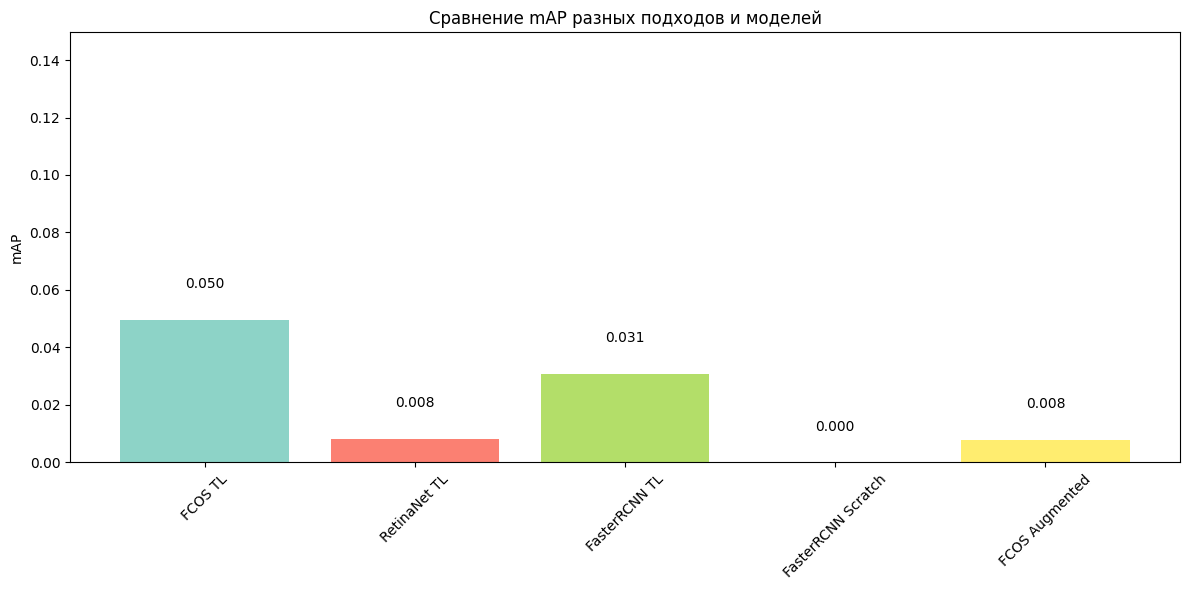

In [37]:
print("\n" + "="*80)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

comparison_data = {}
for model_name in ['FCOS', 'RetinaNet', 'FasterRCNN']:
    if model_name in results and results[model_name]['best_map'] > 0:
        comparison_data[f'{model_name} TL'] = results[model_name]['best_map']

if scratch_success:
    comparison_data['FasterRCNN Scratch'] = scratch_best_map

if augmented_success and results:
    best_model_name = max(results.items(), key=lambda x: x[1]['best_map'])[0]
    comparison_data[f'{best_model_name} Augmented'] = augmented_best_map

plt.figure(figsize=(12, 6))
models_names = list(comparison_data.keys())
maps = list(comparison_data.values())

colors = plt.cm.Set3(np.linspace(0, 1, len(models_names)))
bars = plt.bar(models_names, maps, color=colors)
plt.title('Сравнение mAP разных подходов и моделей')
plt.ylabel('mAP')
plt.xticks(rotation=45)
plt.ylim(0, max(maps) + 0.1 if maps else 1)

for bar, map_val in zip(bars, maps):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{map_val:.3f}', 
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
print("\nДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ:")
print("="*50)

if results:
    best_model_name = max(results.items(), key=lambda x: x[1]['best_map'])[0]
    print(f"\n1. ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"   - mAP: {results[best_model_name]['best_map']:.4f}")
    print(f"   - Время обучения: {results[best_model_name]['training_time']:.2f}s")
    print(f"   - Параметры: {results[best_model_name]['model_params']:,}")

if 'FasterRCNN TL' in comparison_data and 'FasterRCNN Scratch' in comparison_data:
    print(f"\n2. СРАВНЕНИЕ TRANSFER LEARNING VS SCRATCH:")
    print(f"   - FasterRCNN TL: {comparison_data['FasterRCNN TL']:.4f}")
    print(f"   - FasterRCNN Scratch: {comparison_data['FasterRCNN Scratch']:.4f}")
    improvement = ((comparison_data['FasterRCNN TL'] - comparison_data['FasterRCNN Scratch']) / comparison_data['FasterRCNN Scratch'] * 100)
    print(f"   - Улучшение от TL: {improvement:+.1f}%")

if augmented_success and results:
    print(f"\n3. ЭФФЕКТ АУГМЕНТАЦИЙ:")
    print(f"   - {best_model_name} без аугментаций: {results[best_model_name]['best_map']:.4f}")
    print(f"   - {best_model_name} с аугментациями: {augmented_best_map:.4f}")
    aug_improvement = ((augmented_best_map - results[best_model_name]['best_map']) / results[best_model_name]['best_map'] * 100)
    print(f"   - Влияние аугментаций: {aug_improvement:+.1f}%")

print(f"\n4. СРАВНЕНИЕ АРХИТЕКТУР:")
for model_name in ['FCOS', 'RetinaNet', 'FasterRCNN']:
    if model_name in results and results[model_name]['best_map'] > 0:
        print(f"   - {model_name}: {results[model_name]['best_map']:.4f}")

final_report = {
    "best_model": best_model_name if results else "None",
    "best_mAP": results[best_model_name]['best_map'] if results else 0,
    "model_comparison": comparison_data,
    "training_time_comparison": {
        model_name: results[model_name]['training_time'] for model_name in results
    }
}

final_report["training_time_comparison"]["FasterRCNN_Scratch"] = scratch_training_time
final_report["training_time_comparison"][f"{best_model_name}_Augmented"] = augmented_training_time

with open('final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

if results:
    print(f"Предсказания лучшей модели сохранены в best_{best_model_name}_TL_predictions.json")

print("\n" + "="*80)
print("ВЫПОЛНЕНИЕ ЗАВЕРШЕНО")
print("="*80)


ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ:

1. ЛУЧШАЯ МОДЕЛЬ: FCOS
   - mAP: 0.0496
   - Время обучения: 1097.61s
   - Параметры: 32,078,285

2. СРАВНЕНИЕ TRANSFER LEARNING VS SCRATCH:
   - FasterRCNN TL: 0.0308
   - FasterRCNN Scratch: 0.0000
   - Улучшение от TL: +132458.8%

3. ЭФФЕКТ АУГМЕНТАЦИЙ:
   - FCOS без аугментаций: 0.0496
   - FCOS с аугментациями: 0.0079
   - Влияние аугментаций: -84.1%

4. СРАВНЕНИЕ АРХИТЕКТУР:
   - FCOS: 0.0496
   - RetinaNet: 0.0082
   - FasterRCNN: 0.0308
Предсказания лучшей модели сохранены в best_FCOS_TL_predictions.json

ВЫПОЛНЕНИЕ ЗАВЕРШЕНО
